In [ ]:
# K-Nearest Neighbors (KNN) Algorithm
"""
K-Nearest Neighbors (KNN) is a supervised machine learning algorithm that can be used for both:
1. Classification
2. Regression
However, it is mostly used for classification problems.

Characteristics of KNN
- Non-parametric algorithm
    It does not make assumptions about the underlying data distribution.
- Lazy Learner Algorithm
    No explicit training phase.
    Stores the entire dataset and makes predictions when new data arrives.

K in KNN
K represents the number of nearest neighbors considered for prediction.
K is a hyperparameter.

Example:
K = 3 → Consider the 3 nearest neighbors.
K = 5 → Consider the 5 nearest neighbors.

Working of KNN (Classification)
Suppose we have two classes:
🔴 Red Class
🔵 Blue Class
Example : 
      🔴     🔴

             ● ? (New Point)

      🔵     🔵     🔵
If K = 3:

Find the 3 nearest neighbors.
Suppose among them:
2 are Blue
1 is Red

Therefore, the new point will be classified as Blue.

"""

In [ ]:
"""
Distance Calculation in KNN
To find the nearest neighbors, distance is calculated using:
1. Euclidean Distance
It measures the straight-line distance between two points.
d=sqrt ( (x2​−x1​)^2+(y2​−y1​)^2 )
​
2. Manhattan Distance
It measures distance along horizontal and vertical paths.
d=∣x2​−x1​∣+∣y2​−y1​∣
"""

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 

In [2]:
dataset = pd.read_csv("Social_Network_Ads.csv")
dataset.head(3)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0


In [3]:
dataset.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

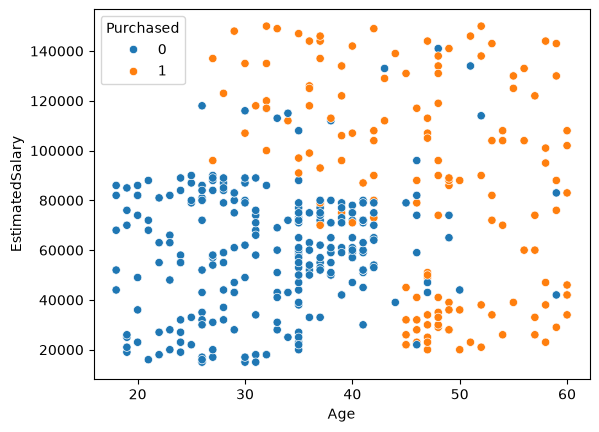

In [4]:
sns.scatterplot(x="Age", y="EstimatedSalary",data=dataset,hue="Purchased")
plt.show()

In [5]:
x = dataset.iloc[:,:-1]
y = dataset["Purchased"]
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x),columns=x.columns)

In [6]:
from sklearn.model_selection import train_test_split
x_train , x_test,y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)
knn.score(x_test,y_test)*100

92.5

In [ ]:
"""
n_neighbors : int, default=5
    Number of neighbors to use by default for :meth:`kneighbors` queries.
p : float, default=2 {euclidean}
    Power parameter for the Minkowski metric. When p = 1, this is equivalent
    to using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.
    For arbitrary p, minkowski_distance (l_p) is used. This parameter is expected
    to be positive.
"""

In [10]:
#Overfitting check
knn.score(x_test,y_test)*100 , knn.score(x_train,y_train)*100 , knn.score(x_test,y_test)*100-knn.score(x_train,y_train)*100

(92.5, 90.9375, 1.5625)

In [13]:
for i in range(1,30):
    knn1 = KNeighborsClassifier(n_neighbors=i)
    knn1.fit(x_train,y_train)
    print( i , knn.score(x_test,y_test)*100 , knn.score(x_train,y_train)*100 , knn.score(x_test,y_test)*100-knn.score(x_train,y_train)*100)

1 92.5 90.9375 1.5625
2 92.5 90.9375 1.5625
3 92.5 90.9375 1.5625
4 92.5 90.9375 1.5625
5 92.5 90.9375 1.5625
6 92.5 90.9375 1.5625
7 92.5 90.9375 1.5625
8 92.5 90.9375 1.5625
9 92.5 90.9375 1.5625
10 92.5 90.9375 1.5625
11 92.5 90.9375 1.5625
12 92.5 90.9375 1.5625
13 92.5 90.9375 1.5625
14 92.5 90.9375 1.5625
15 92.5 90.9375 1.5625
16 92.5 90.9375 1.5625
17 92.5 90.9375 1.5625
18 92.5 90.9375 1.5625
19 92.5 90.9375 1.5625
20 92.5 90.9375 1.5625
21 92.5 90.9375 1.5625
22 92.5 90.9375 1.5625
23 92.5 90.9375 1.5625
24 92.5 90.9375 1.5625
25 92.5 90.9375 1.5625
26 92.5 90.9375 1.5625
27 92.5 90.9375 1.5625
28 92.5 90.9375 1.5625
29 92.5 90.9375 1.5625


C:\Users\Pushpendra\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


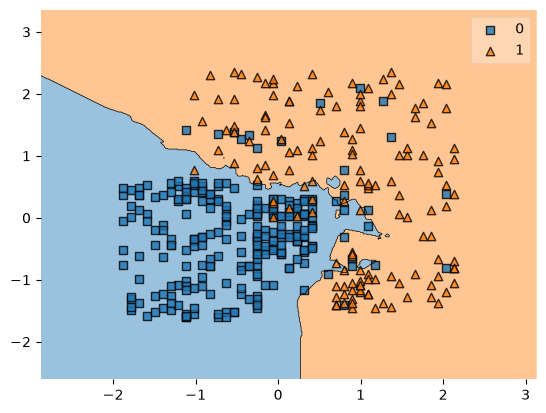

In [15]:
# Decision Boundary
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf=knn)
plt.show()